In [ ]:
!pip install xgboost opencv-python kagglehub -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [ ]:
#path
path = kagglehub.dataset_download(
    "sartajbhuvaji/brain-tumor-classification-mri"
)

print("Dataset Path:", path)

100%|██████████| 86.8M/86.8M [00:00<00:00, 126MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3


In [ ]:
#define classes
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

In [ ]:
#load dataset
IMG_SIZE = 200

def load_images(folder_path):

    X = []
    Y = []

    for cls, label in classes.items():

        class_path = os.path.join(folder_path, cls)

        for filename in os.listdir(class_path):

            img_path = os.path.join(class_path, filename)

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is not None:

                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )

                img = img.flatten() / 255.0

                X.append(img)

                Y.append(label)

    return np.array(X, dtype=np.float32), np.array(Y)


# LOAD TRAINING DATA
train_path = os.path.join(path, "Training")

print("Loading Training Images...")

X_train, Y_train = load_images(train_path)

# LOAD TESTING DATA
test_path = os.path.join(path, "Testing")

print("Loading Testing Images...")

X_test, Y_test = load_images(test_path)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Loading Training Images...
Loading Testing Images...
Training Shape : (2870, 40000)
Testing Shape  : (394, 40000)


In [ ]:
#training percentages
train_sizes = [0.2, 0.4, 0.6, 0.8]



TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 574
Testing Samples  : 394

Training XGBoost Model...
Training Completed
Training Accuracy : 0.9965156794425087
Testing Accuracy  : 0.4467005076142132
F1 Score          : 0.4124713267793235

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.38      0.85      0.52       105
 Pituitary Tumor       0.64      0.41      0.50        74
    Glioma Tumor       0.44      0.12      0.19       100
Meningioma Tumor       0.54      0.39      0.45       115

        accuracy                           0.45       394
       macro avg       0.50      0.44      0.41       394
    weighted avg       0.49      0.45      0.41       394



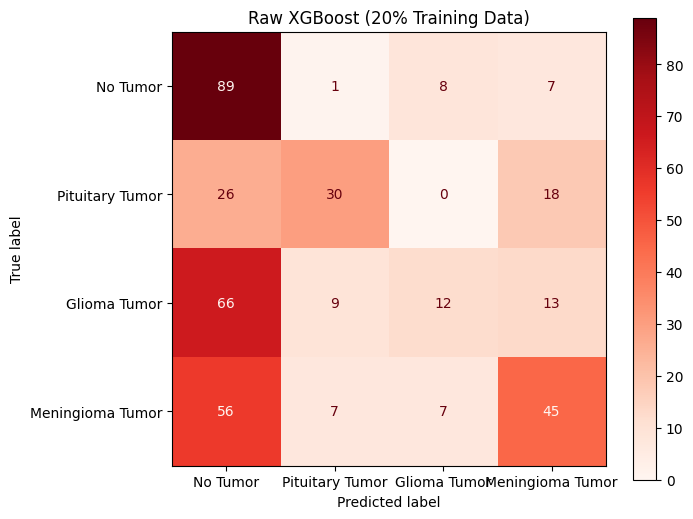


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1148
Testing Samples  : 394

Training XGBoost Model...
Training Completed
Training Accuracy : 0.9599303135888502
Testing Accuracy  : 0.5253807106598984
F1 Score          : 0.4758404344864288

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.43      0.92      0.59       105
 Pituitary Tumor       0.71      0.36      0.48        74
    Glioma Tumor       0.67      0.10      0.17       100
Meningioma Tumor       0.63      0.63      0.63       115

        accuracy                           0.53       394
       macro avg       0.61      0.51      0.47       394
    weighted avg       0.60      0.53      0.48       394



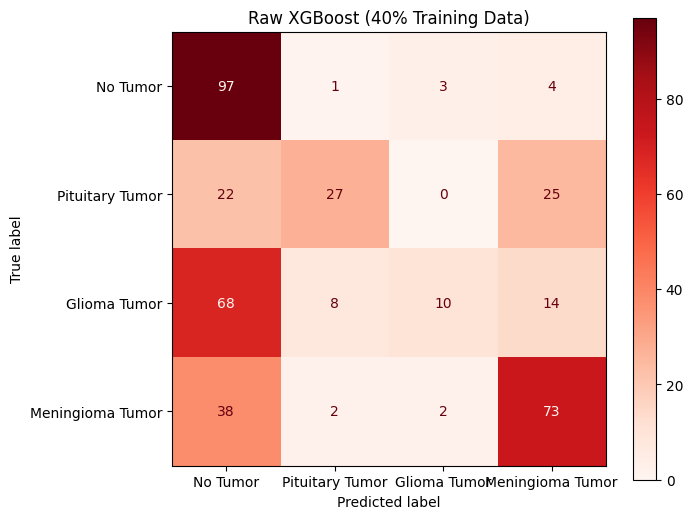


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1722
Testing Samples  : 394

Training XGBoost Model...
Training Completed
Training Accuracy : 0.9413472706155633
Testing Accuracy  : 0.5228426395939086
F1 Score          : 0.47683823685649324

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.41      0.95      0.57       105
 Pituitary Tumor       0.77      0.32      0.46        74
    Glioma Tumor       0.69      0.11      0.19       100
Meningioma Tumor       0.69      0.62      0.65       115

        accuracy                           0.52       394
       macro avg       0.64      0.50      0.47       394
    weighted avg       0.63      0.52      0.48       394



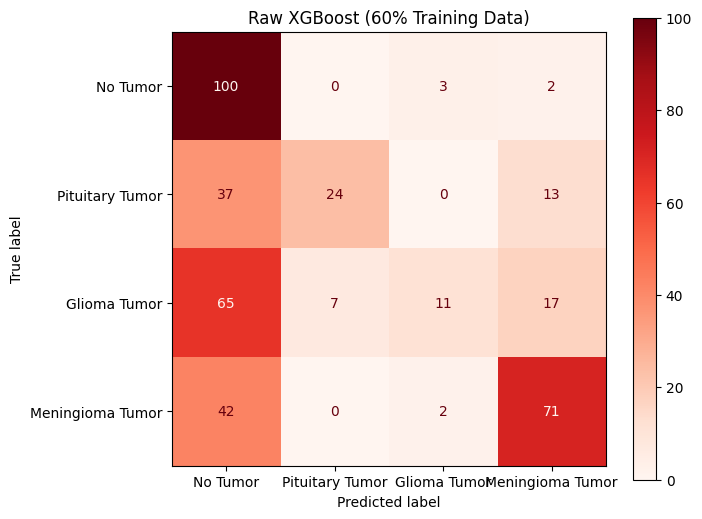


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 2296
Testing Samples  : 394

Training XGBoost Model...
Training Completed
Training Accuracy : 0.9372822299651568
Testing Accuracy  : 0.550761421319797
F1 Score          : 0.49572067319913615

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.43      0.98      0.60       105
 Pituitary Tumor       0.75      0.32      0.45        74
    Glioma Tumor       0.83      0.10      0.18       100
Meningioma Tumor       0.71      0.70      0.70       115

        accuracy                           0.55       394
       macro avg       0.68      0.53      0.48       394
    weighted avg       0.67      0.55      0.50       394



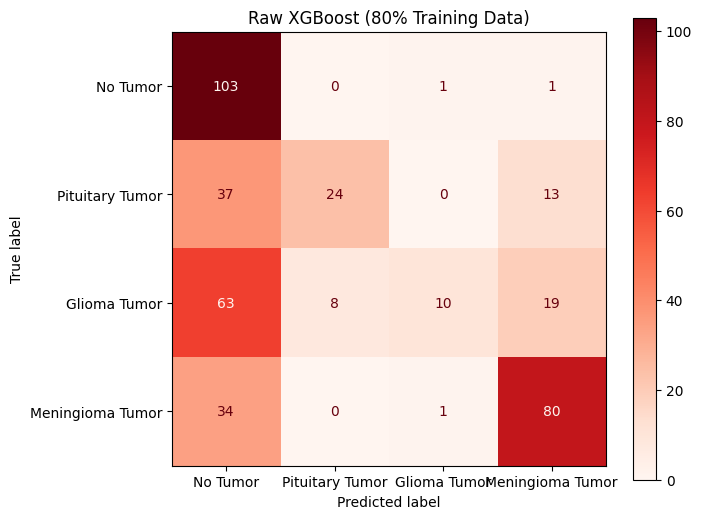

In [ ]:
#xgboost training
train_acc_list = []

test_acc_list = []

f1_list = []

labels = []

for train_size in train_sizes:

    print("\n======================================")
    print(f"TRAINING DATA USED : {int(train_size*100)}%")
    print("TESTING DATA USED  : 100% Official Test Set")
    print("======================================")

    # TAKE SUBSET OF TRAINING DATA
    xtrain, _, ytrain, _ = train_test_split(
        X_train,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    print("Training Samples :", xtrain.shape[0])
    print("Testing Samples  :", X_test.shape[0])

    # XGBOOST MODEL
    xgb = XGBClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.3,
        reg_lambda=5,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining XGBoost Model...")

    xgb.fit(xtrain, ytrain)

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(xtrain)

    test_pred = xgb.predict(X_test)

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("F1 Score          :", f1)

    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(Y_test, test_pred)

    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Reds',
        colorbar=True
    )

    plt.title(
        f"Raw XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.show()

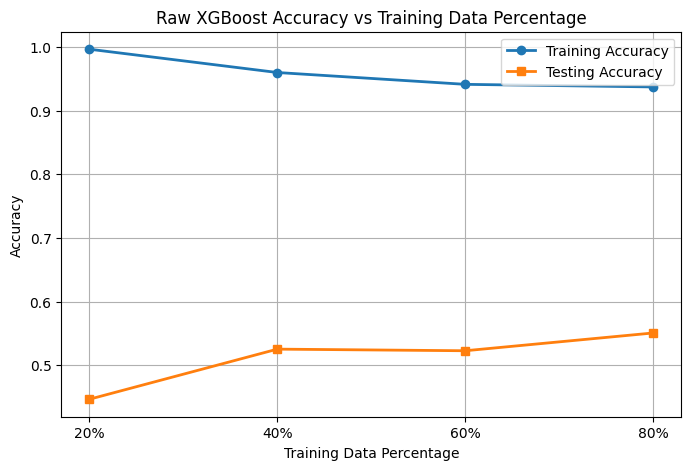

In [ ]:
#accuracy plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Training Data Percentage")
plt.ylabel("Accuracy")
plt.title("Raw XGBoost Accuracy vs Training Data Percentage")
plt.legend()
plt.grid(True)
plt.show()

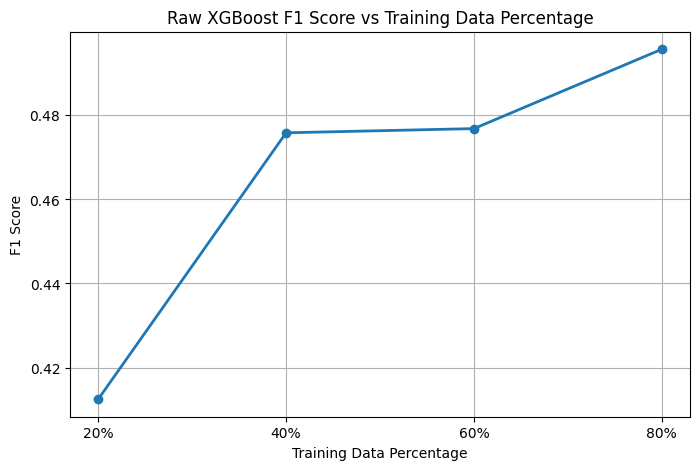

In [ ]:
#f1_plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Training Data Percentage")
plt.ylabel("F1 Score")
plt.title("Raw XGBoost F1 Score vs Training Data Percentage")
plt.grid(True)
plt.show()

In [ ]:
#results table
results_df = pd.DataFrame({
    'Training Data Used': labels,
    'Training Accuracy': train_acc_list,
    'Testing Accuracy': test_acc_list,
    'F1 Score': f1_list
})

print(results_df)

  Training Data Used  Training Accuracy  Testing Accuracy  F1 Score
0                20%           0.996516          0.446701  0.412471
1                40%           0.959930          0.525381  0.475840
2                60%           0.941347          0.522843  0.476838
3                80%           0.937282          0.550761  0.495721


In [ ]:
#predictions on samples
def display_samples(folder, title, num_samples=9):

    valid_ext = ('.jpg', '.jpeg', '.png')

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    plt.figure(figsize=(12,8))

    for i, filename in enumerate(imgs):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        img_flat = img.flatten()/255.0

        pred = xgb.predict([img_flat])[0]
        plt.subplot(3,3,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(dec[pred])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

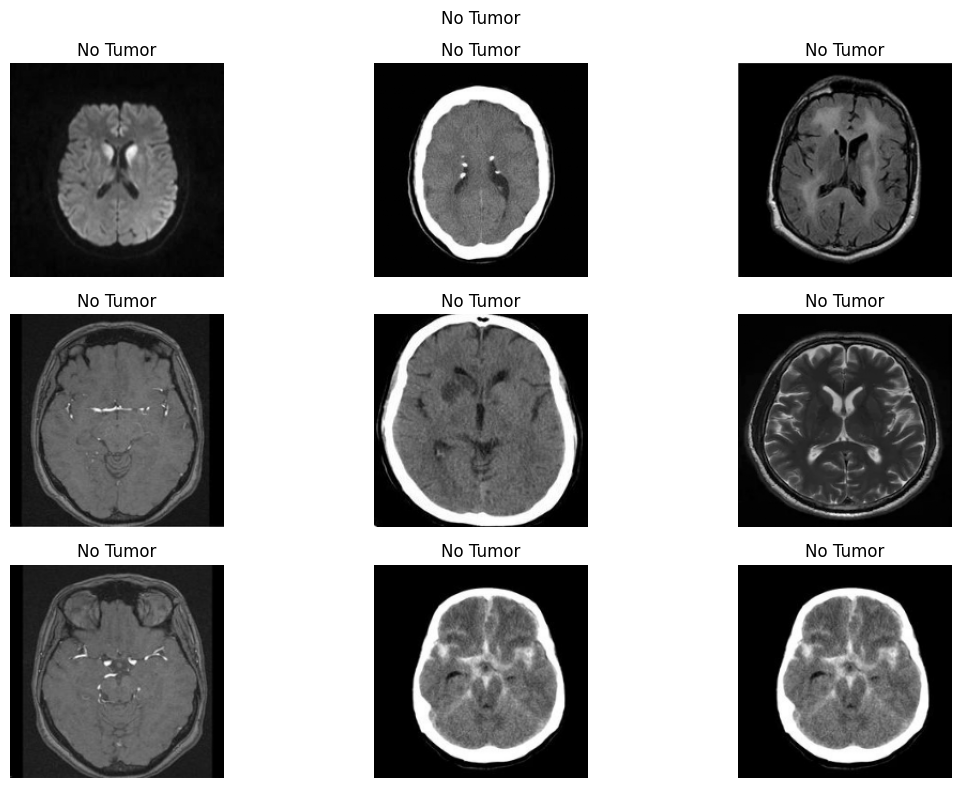

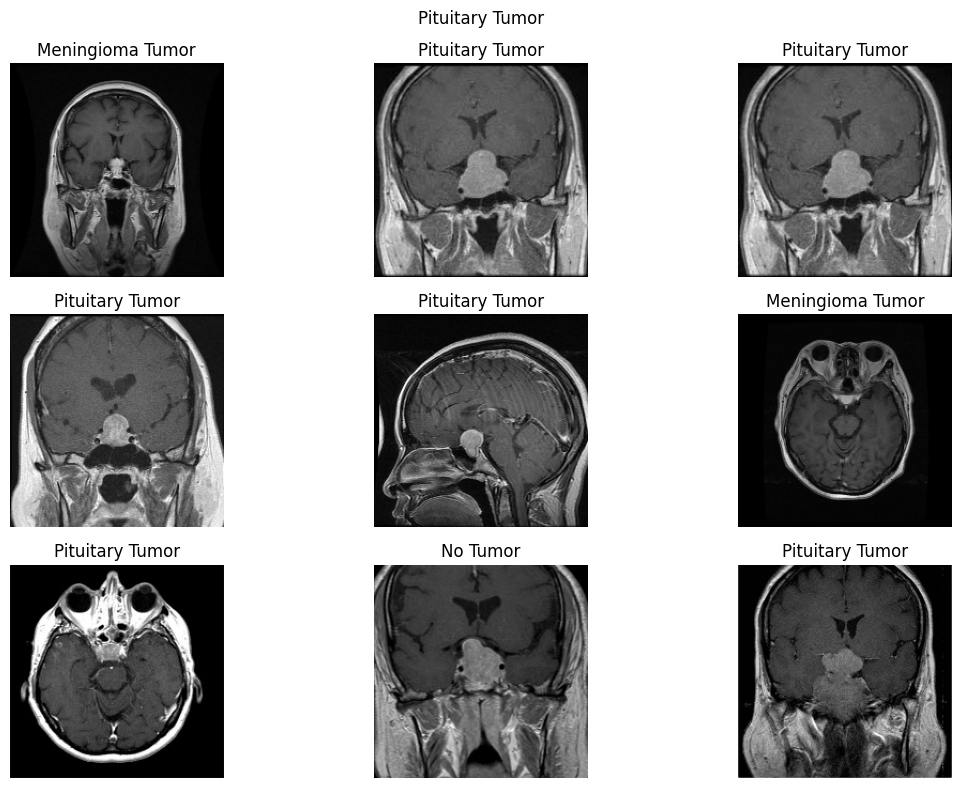

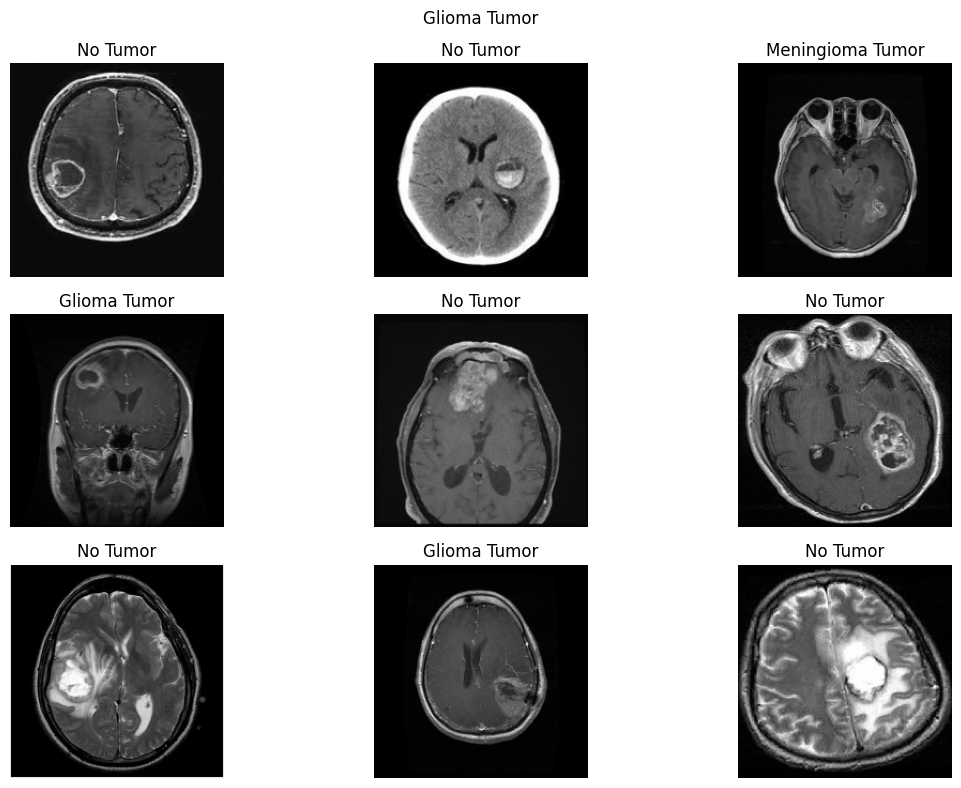

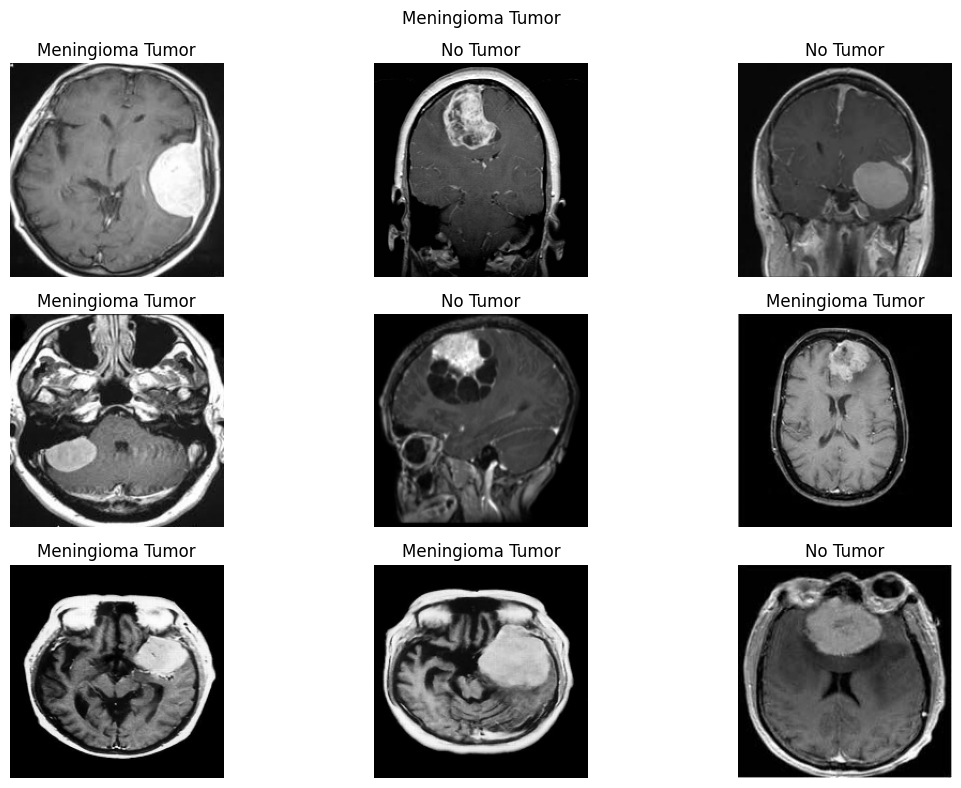

In [ ]:
#display predictions
for tumor_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        tumor_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            tumor_folder.replace("_"," ").title()
        )

In [ ]:
#dataset_distribution
tumor_counts = {
    dec[label]: int(np.sum(Y_train == label))
    for label in classes.values()
}

df = pd.DataFrame({
    'Tumor Type': list(tumor_counts.keys()),
    'Count': list(tumor_counts.values())
})

print(df)

         Tumor Type  Count
0          No Tumor    395
1   Pituitary Tumor    827
2      Glioma Tumor    826
3  Meningioma Tumor    822


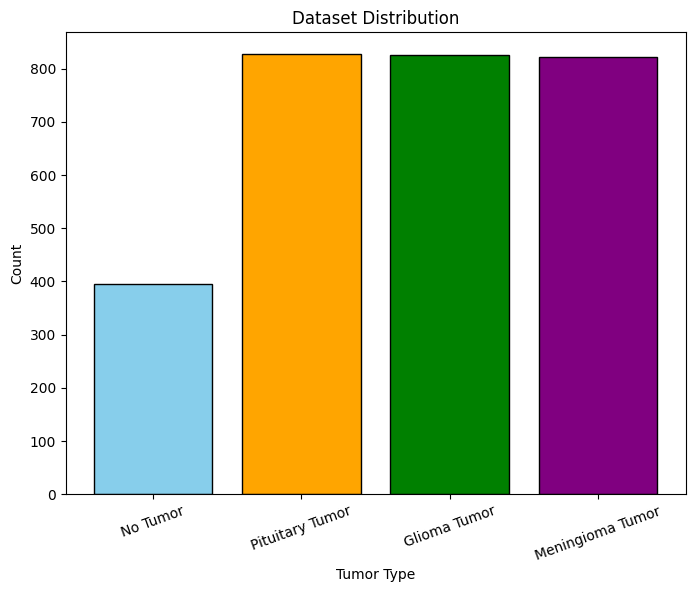

In [ ]:
#distribution plot
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8,6))

for label, color in zip(classes.values(), colors):

    plt.bar(
        dec[label],
        int(np.sum(Y_train == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Tumor Type")

plt.ylabel("Count")

plt.title("Dataset Distribution")

plt.xticks(rotation=20)

plt.show()

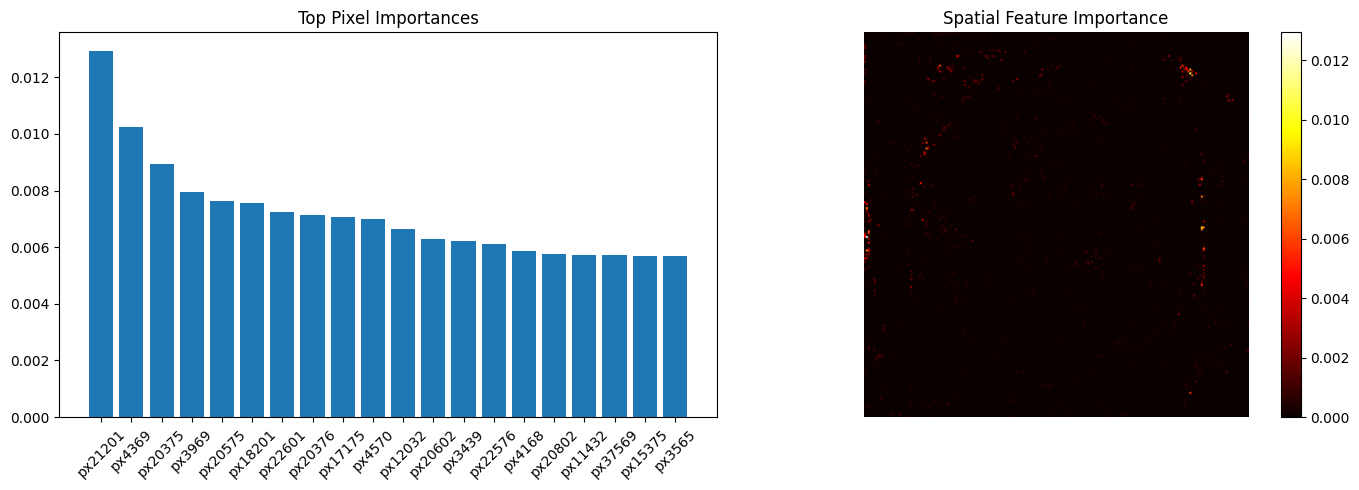

In [ ]:
#feature importance
importances = xgb.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

fig, axes = plt.subplots(1,2, figsize=(14,5))

# BAR CHART
axes[0].bar(
    range(20),
    importances[top_idx]
)

axes[0].set_xticks(range(20))

axes[0].set_xticklabels(
    [f"px{idx}" for idx in top_idx],
    rotation=45
)

axes[0].set_title("Top Pixel Importances")

# SAFE HEATMAP
importance_map = np.zeros(IMG_SIZE * IMG_SIZE)

importance_map[:len(importances)] = importances

importance_map = importance_map.reshape(
    IMG_SIZE,
    IMG_SIZE
)

im = axes[1].imshow(
    importance_map,
    cmap='hot'
)

axes[1].set_title(
    "Spatial Feature Importance"
)

axes[1].axis('off')

plt.colorbar(im)
plt.tight_layout()
plt.show()